# When Does Feature Selection Actually Matter?
### A Data-Driven Comparison Across Machine Learning Algorithms

---

## The Central Question

You've probably heard that **feature selection improves model performance** — but is that always true? Does it matter which algorithm you're using?

The honest answer: **it depends entirely on the algorithm.** Some algorithms are naturally robust to irrelevant features and unscaled data. Others fall apart without careful preprocessing. Understanding *why* is one of the most practically useful things you can learn in applied machine learning.

This notebook demonstrates the truth empirically, using the same dataset and the same features, across four algorithms:

| Algorithm | Sensitive to Irrelevant Features? | Sensitive to Scale? |
|---|---|---|
| **Random Forest** | Weakly | ❌ No |
| **Logistic Regression** | Yes | ✅ Strongly |
| **k-Nearest Neighbors (kNN)** | ✅ Strongly | ✅ Strongly |
| **SVM (RBF Kernel)** | Moderately | ✅ Strongly |

We will test each algorithm under four conditions:
1. All features, no scaling
2. All features, scaled
3. Selected features only, no scaling
4. Selected features, scaled

Then we'll look at the numbers and ask: *what story does the data tell?*

---

## Part 1: Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Part 2: Dataset Creation

We simulate a credit card fraud detection dataset. This domain is chosen because it naturally produces:
- **Class imbalance** (5% fraud) — a realistic challenge
- **Overlapping distributions** — fraud and legitimate transactions share similar ranges, so the separation is not trivial
- **Wildly different feature scales** — account age in days vs. a binary flag vs. amounts in dollars
- **Noise features** designed to actively mislead: some have spurious correlations, one is collinear with a real feature

All feature *names* and the DataFrame structure match the original notebook so downstream code is unaffected.

In [2]:
np.random.seed(42)
n_samples = 5000
n_fraud   = 250     # 5% fraud rate
n_legit   = n_samples - n_fraud

# --- Informative features (real signal, but imperfect / overlapping) ---

transaction_amount = np.concatenate([
    np.random.exponential(120, n_legit),
    np.random.exponential(180, n_fraud)    # Fraud is larger on average, but distributions overlap heavily
]) + np.random.normal(0, 30, n_samples)

transaction_hour = np.concatenate([
    np.random.normal(13, 5, n_legit) % 24,
    np.random.normal(22, 6, n_fraud) % 24  # Fraud skews to evening/night — but still overlaps
])

days_since_last_transaction = np.concatenate([
    np.random.exponential(4, n_legit),
    np.random.exponential(7, n_fraud)
]) + np.random.exponential(1, n_samples)

merchant_category_code = np.concatenate([
    np.random.choice([5411, 5541, 5812, 5921], n_legit),
    np.random.choice([5999, 5122, 4816, 5541, 5812], n_fraud)  # Fraud uses some normal MCCs too
])

# Stored in METERS intentionally — creates extreme scale difference vs. other features
distance_from_home_km = np.concatenate([
    np.random.exponential(15, n_legit),
    np.random.exponential(80, n_fraud)
]) * 1000  # <-- values now 0 to ~500,000

online_transaction = np.concatenate([
    np.random.choice([0, 1], n_legit, p=[0.58, 0.42]),
    np.random.choice([0, 1], n_fraud, p=[0.38, 0.62])
])

transactions_last_24h = np.concatenate([
    np.random.poisson(2.5, n_legit),
    np.random.poisson(5, n_fraud)          # Meaningful signal, but Poisson distributions heavily overlap
])

card_present = np.concatenate([
    np.random.choice([0, 1], n_legit, p=[0.28, 0.72]),
    np.random.choice([0, 1], n_fraud, p=[0.65, 0.35])
])

international_transaction = np.concatenate([
    np.random.choice([0, 1], n_legit, p=[0.93, 0.07]),
    np.random.choice([0, 1], n_fraud, p=[0.72, 0.28])
])

# Account age — values span 0 to 5,000+ (very different scale from binary features)
customer_age_days = np.concatenate([
    np.random.normal(1400, 700, n_legit),
    np.random.normal(900, 600, n_fraud)    # Fraud more likely on newer accounts, but overlapping
]).clip(0)

# --- Noise features (designed to actively mislead, not just be neutral) ---

spurious_signal = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)])

# Noise 1 & 2: spuriously correlated with target IN THIS SAMPLE but won't generalize
noise_feature_1 = spurious_signal * 0.4 + np.random.randn(n_samples) * 1.2
noise_feature_2 = spurious_signal * 0.3 + np.random.randn(n_samples) * 1.5

# Noise 3: collinear with transaction_amount — wastes model capacity, adds no new info
noise_feature_3 = transaction_amount / 1000 * 0.5 + np.random.randn(n_samples) * 2.0

# Noise 4: pure random noise at a LARGE scale — will dominate kNN/SVM without scaling
noise_feature_4 = np.random.randn(n_samples) * 500

# Noise 5: pure random noise at a small scale
noise_feature_5 = np.random.uniform(0, 1, n_samples)

data = {
    'transaction_amount':          transaction_amount,
    'transaction_hour':            transaction_hour,
    'days_since_last_transaction': days_since_last_transaction,
    'merchant_category_code':      merchant_category_code,
    'distance_from_home_km':       distance_from_home_km,
    'online_transaction':          online_transaction,
    'transactions_last_24h':       transactions_last_24h,
    'card_present':                card_present,
    'international_transaction':   international_transaction,
    'customer_age_days':           customer_age_days,
    'noise_feature_1':             noise_feature_1,
    'noise_feature_2':             noise_feature_2,
    'noise_feature_3':             noise_feature_3,
    'noise_feature_4':             noise_feature_4,
    'noise_feature_5':             noise_feature_5,
}

y          = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)])
shuffle_idx = np.random.permutation(n_samples)
df         = pd.DataFrame({k: v[shuffle_idx] for k, v in data.items()})
df['is_fraud'] = y[shuffle_idx]

print('💳 Credit Card Fraud Detection Dataset')
print('=' * 65)
print(f'Total transactions:      {len(df):,}')
print(f'Fraudulent transactions: {int(df.is_fraud.sum()):,} ({df.is_fraud.mean()*100:.1f}%)')
print(f'Legitimate transactions: {int((1-df.is_fraud).sum()):,} ({(1-df.is_fraud.mean())*100:.1f}%)')
print(f'Total features:          {len(df.columns)-1}')
print(f'  → Signal features:     10')
print(f'  → Noise features:      5')

💳 Credit Card Fraud Detection Dataset
Total transactions:      5,000
Fraudulent transactions: 250 (5.0%)
Legitimate transactions: 4,750 (95.0%)
Total features:          15
  → Signal features:     10
  → Noise features:      5


---
## Part 3: Visualizing the Scale Problem

Before we run any models, let's visualize the core issue that makes **feature scaling** necessary for some algorithms.

> **Key idea:** When one feature has values in the hundreds of thousands and another is a 0/1 binary flag, algorithms that rely on *distance* or *gradient magnitude* will essentially ignore the small-scale features. The math is biased before learning even begins.

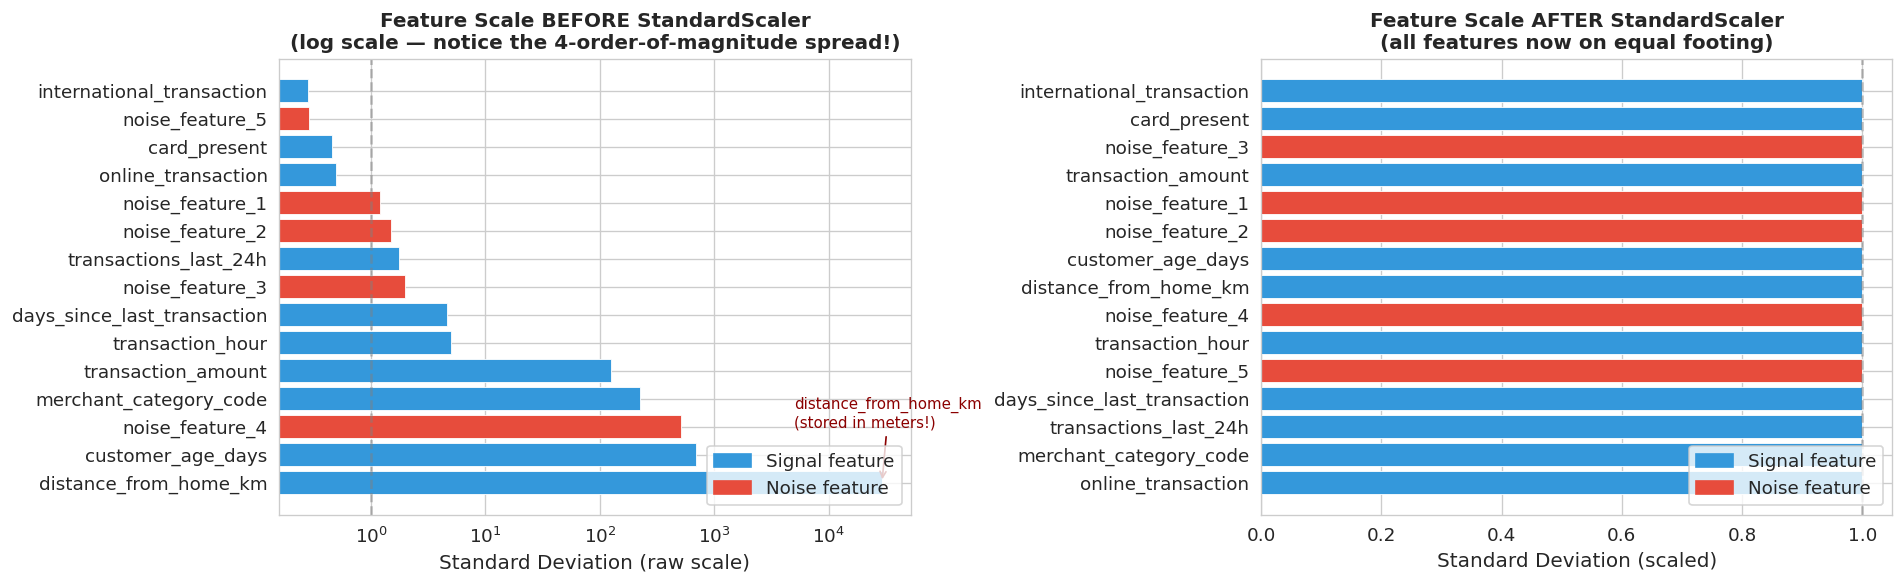


📏 Raw feature standard deviations:
distance_from_home_km          29086.0
customer_age_days                691.7
noise_feature_4                  509.0
merchant_category_code           225.7
transaction_amount               125.7
transaction_hour                   5.0
days_since_last_transaction        4.6
noise_feature_3                    2.0
transactions_last_24h              1.7
noise_feature_2                    1.5
noise_feature_1                    1.2
online_transaction                 0.5
card_present                       0.5
noise_feature_5                    0.3
international_transaction          0.3

⚠️  Ratio of largest to smallest std: 103192x
   → distance_from_home_km will dominate kNN and SVM distance calculations!


In [3]:
X = df.drop('is_fraud', axis=1)
feature_stds = X.std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: raw standard deviations ---
colors = ['#e74c3c' if 'noise' in f else '#3498db' for f in feature_stds.index]
bars = axes[0].barh(feature_stds.index, feature_stds.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Standard Deviation (raw scale)', fontsize=12)
axes[0].set_title('Feature Scale BEFORE StandardScaler\n(log scale — notice the 4-order-of-magnitude spread!)', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].axvline(1, color='gray', linestyle='--', alpha=0.5, label='std = 1')

signal_patch = mpatches.Patch(color='#3498db', label='Signal feature')
noise_patch  = mpatches.Patch(color='#e74c3c', label='Noise feature')
axes[0].legend(handles=[signal_patch, noise_patch], loc='lower right')

# Annotate the extremes
axes[0].annotate('distance_from_home_km\n(stored in meters!)',
    xy=(feature_stds['distance_from_home_km'], list(feature_stds.index).index('distance_from_home_km')),
    xytext=(5000, 2), fontsize=9, color='darkred',
    arrowprops=dict(arrowstyle='->', color='darkred'))

# --- Right: after StandardScaler ---
from sklearn.preprocessing import StandardScaler
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
scaled_stds = X_scaled.std().sort_values(ascending=False)
colors_s = ['#e74c3c' if 'noise' in f else '#3498db' for f in scaled_stds.index]
axes[1].barh(scaled_stds.index, scaled_stds.values, color=colors_s, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Standard Deviation (scaled)', fontsize=12)
axes[1].set_title('Feature Scale AFTER StandardScaler\n(all features now on equal footing)', fontsize=12, fontweight='bold')
axes[1].axvline(1, color='gray', linestyle='--', alpha=0.5, label='std = 1')
axes[1].legend(handles=[signal_patch, noise_patch], loc='lower right')

plt.tight_layout()
plt.savefig('/tmp/scale_comparison.png', bbox_inches='tight')
plt.show()

print('\n📏 Raw feature standard deviations:')
print(feature_stds.round(1).to_string())
print(f'\n⚠️  Ratio of largest to smallest std: {feature_stds.max()/feature_stds.min():.0f}x')
print('   → distance_from_home_km will dominate kNN and SVM distance calculations!')

---
## Part 4: Identifying Signal vs. Noise Features

Before training models, we use **Mutual Information** to score each feature's statistical relationship with the target. This is what feature selection algorithms do internally.

> **Mutual Information** measures how much knowing a feature's value reduces uncertainty about the target. A score of 0 means the feature tells us nothing about fraud; a higher score means stronger signal.

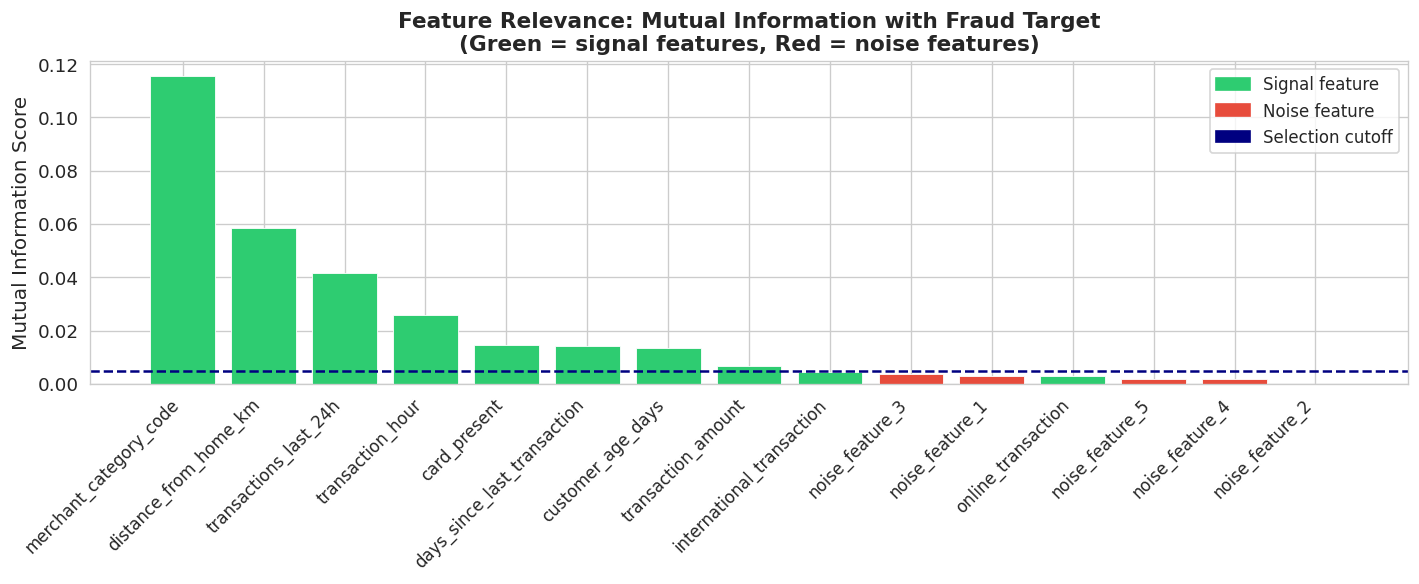

✅ Selected 10 signal features:
   merchant_category_code              MI = 0.1155
   distance_from_home_km               MI = 0.0586
   transactions_last_24h               MI = 0.0415
   transaction_hour                    MI = 0.0260
   card_present                        MI = 0.0144
   days_since_last_transaction         MI = 0.0142
   customer_age_days                   MI = 0.0134
   transaction_amount                  MI = 0.0066
   international_transaction           MI = 0.0046
   online_transaction                  MI = 0.0030

🚫 Excluded 5 noise features:
   noise_feature_3                     MI = 0.0037
   noise_feature_1                     MI = 0.0031
   noise_feature_5                     MI = 0.0019
   noise_feature_4                     MI = 0.0016
   noise_feature_2                     MI = 0.0000


In [4]:
y_full = df['is_fraud'].values

# Compute mutual information scores
mi_scores = mutual_info_classif(X, y_full, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'MI_score': mi_scores})
mi_df = mi_df.sort_values('MI_score', ascending=False).reset_index(drop=True)
mi_df['type'] = mi_df['feature'].apply(lambda f: 'Noise' if 'noise' in f else 'Signal')

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if t == 'Noise' else '#2ecc71' for t in mi_df['type']]
bars = ax.bar(mi_df['feature'], mi_df['MI_score'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Relevance: Mutual Information with Fraud Target\n'
             '(Green = signal features, Red = noise features)', fontsize=13, fontweight='bold')
ax.set_xticklabels(mi_df['feature'], rotation=45, ha='right', fontsize=10)

# Draw selection threshold
threshold = mi_df[mi_df['type']=='Noise']['MI_score'].max() + 0.001
ax.axhline(threshold, color='navy', linestyle='--', linewidth=1.5, label=f'Selection threshold')
ax.legend(fontsize=11)

signal_patch = mpatches.Patch(color='#2ecc71', label='Signal feature')
noise_patch  = mpatches.Patch(color='#e74c3c', label='Noise feature')
ax.legend(handles=[signal_patch, noise_patch,
          mpatches.Patch(color='navy', label='Selection cutoff')], fontsize=10)
plt.tight_layout()
plt.show()

# Define the top feature set
top_features = mi_df[mi_df['type'] == 'Signal']['feature'].tolist()
print(f'✅ Selected {len(top_features)} signal features:')
for f in top_features:
    score = mi_df[mi_df['feature']==f]['MI_score'].values[0]
    print(f'   {f:<35} MI = {score:.4f}')
print(f'\n🚫 Excluded {len(X.columns) - len(top_features)} noise features:')
for f in mi_df[mi_df['type']=='Noise']['feature']:
    score = mi_df[mi_df['feature']==f]['MI_score'].values[0]
    print(f'   {f:<35} MI = {score:.4f}')

---
## Part 5: The Core Experiment — 4 Algorithms × 4 Conditions

Now we run the central experiment. Each algorithm is tested under all four combinations:

```
Condition A: All features   + No scaling
Condition B: All features   + StandardScaler
Condition C: Selected only  + No scaling
Condition D: Selected only  + StandardScaler  ← the "best practice" condition
```

We use **5-fold stratified cross-validation** instead of a single train/test split. This gives us more reliable estimates and reduces the impact of lucky/unlucky splits.

> **Why stratified?** With only 5% fraud, a random split could accidentally put very few fraud cases in some folds. Stratified CV ensures each fold has the same class ratio as the full dataset.

In [5]:
# --- Prepare data variants ---
scaler = StandardScaler()

X_all        = X.values
X_all_scaled = scaler.fit_transform(X_all)

feature_idx  = [list(X.columns).index(f) for f in top_features]
X_sel        = X_all[:, feature_idx]
X_sel_scaled = X_all_scaled[:, feature_idx]

data_variants = {
    'All Features\n(No Scaling)':     X_all,
    'All Features\n(Scaled)':         X_all_scaled,
    'Selected Features\n(No Scaling)': X_sel,
    'Selected Features\n(Scaled)':     X_sel_scaled,
}

# --- Define algorithms ---
algorithms = {
    'Random Forest':       RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'kNN (k=11)':          KNeighborsClassifier(n_neighbors=11, metric='euclidean'),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
}

# --- Run cross-validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print('🚀 Running 5-fold cross-validation for 4 algorithms × 4 conditions...')
print('   (This may take 1–2 minutes)\n')

for algo_name, model in algorithms.items():
    for condition, X_variant in data_variants.items():
        # Collect per-fold scores
        fold_f1s      = cross_val_score(model, X_variant, y_full, cv=cv, scoring='f1',        n_jobs=-1)
        fold_recalls  = cross_val_score(model, X_variant, y_full, cv=cv, scoring='recall',    n_jobs=-1)
        fold_aucs     = cross_val_score(model, X_variant, y_full, cv=cv, scoring='roc_auc',   n_jobs=-1)
        fold_accs     = cross_val_score(model, X_variant, y_full, cv=cv, scoring='accuracy',  n_jobs=-1)

        results.append({
            'Algorithm':  algo_name,
            'Condition':  condition,
            'F1':         fold_f1s.mean(),
            'F1_std':     fold_f1s.std(),
            'Recall':     fold_recalls.mean(),
            'ROC-AUC':    fold_aucs.mean(),
            'Accuracy':   fold_accs.mean(),
        })
        print(f'  ✓ {algo_name:<22} | {condition.replace(chr(10)," "):<30} | F1={fold_f1s.mean():.3f} ± {fold_f1s.std():.3f}')

results_df = pd.DataFrame(results)
print('\n✅ All experiments complete!')

🚀 Running 5-fold cross-validation for 4 algorithms × 4 conditions...
   (This may take 1–2 minutes)

  ✓ Random Forest          | All Features (No Scaling)      | F1=0.829 ± 0.036
  ✓ Random Forest          | All Features (Scaled)          | F1=0.829 ± 0.036
  ✓ Random Forest          | Selected Features (No Scaling) | F1=0.840 ± 0.038
  ✓ Random Forest          | Selected Features (Scaled)     | F1=0.841 ± 0.034
  ✓ Logistic Regression    | All Features (No Scaling)      | F1=0.710 ± 0.017
  ✓ Logistic Regression    | All Features (Scaled)          | F1=0.713 ± 0.021
  ✓ Logistic Regression    | Selected Features (No Scaling) | F1=0.699 ± 0.027
  ✓ Logistic Regression    | Selected Features (Scaled)     | F1=0.721 ± 0.013
  ✓ kNN (k=11)             | All Features (No Scaling)      | F1=0.450 ± 0.079
  ✓ kNN (k=11)             | All Features (Scaled)          | F1=0.462 ± 0.077
  ✓ kNN (k=11)             | Selected Features (No Scaling) | F1=0.445 ± 0.083
  ✓ kNN (k=11)             | S

---
## Part 6: Results — The Full Picture

> **Why F1-Score instead of accuracy?**  
> With 95% legitimate transactions, a model that labels *everything* as legitimate achieves 95% accuracy. That's useless for fraud detection. **F1-Score** balances precision (how often a fraud alert is real) and recall (what fraction of actual fraud we catch). It's much more informative here.

Read the table below and look for patterns *across* conditions for each algorithm.

In [6]:
# Pivot table: F1 scores
pivot = results_df.pivot(index='Algorithm', columns='Condition', values='F1')
condition_order = list(data_variants.keys())
pivot = pivot[[c for c in condition_order if c in pivot.columns]]

# Rename columns for display
pivot.columns = ['All + No Scale', 'All + Scaled', 'Selected + No Scale', 'Selected + Scaled']

# Highlight best condition per row
styled = pivot.style\
    .format('{:.3f}')\
    .background_gradient(cmap='RdYlGn', axis=1)\
    .set_caption('Mean F1-Score (5-fold CV) — Greener = better')\
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'center')]
    }])

display(styled)

print('\n📌 Delta: improvement from worst to best condition per algorithm:')
for algo in pivot.index:
    worst = pivot.loc[algo].min()
    best  = pivot.loc[algo].max()
    best_cond = pivot.loc[algo].idxmax()
    print(f'  {algo:<22}: +{best - worst:.3f}  (best: {best_cond})')

,All + No Scale,All + Scaled,Selected + No Scale,Selected + Scaled
Algorithm,,,,
Logistic Regression,0.710,0.713,0.699,0.721
Random Forest,0.829,0.829,0.840,0.841
SVM (RBF),0.407,0.752,0.407,0.786
kNN (k=11),0.450,0.462,0.445,0.568



📌 Delta: improvement from worst to best condition per algorithm:
  Logistic Regression   : +0.022  (best: Selected + Scaled)
  Random Forest         : +0.012  (best: Selected + Scaled)
  SVM (RBF)             : +0.379  (best: Selected + Scaled)
  kNN (k=11)            : +0.123  (best: Selected + Scaled)


---
## Part 7: Visualization — The Story in Four Charts

Each subplot shows one algorithm's F1 scores across all four conditions. Look at *how much* the bars differ within each panel — that's the algorithm's sensitivity to preprocessing.

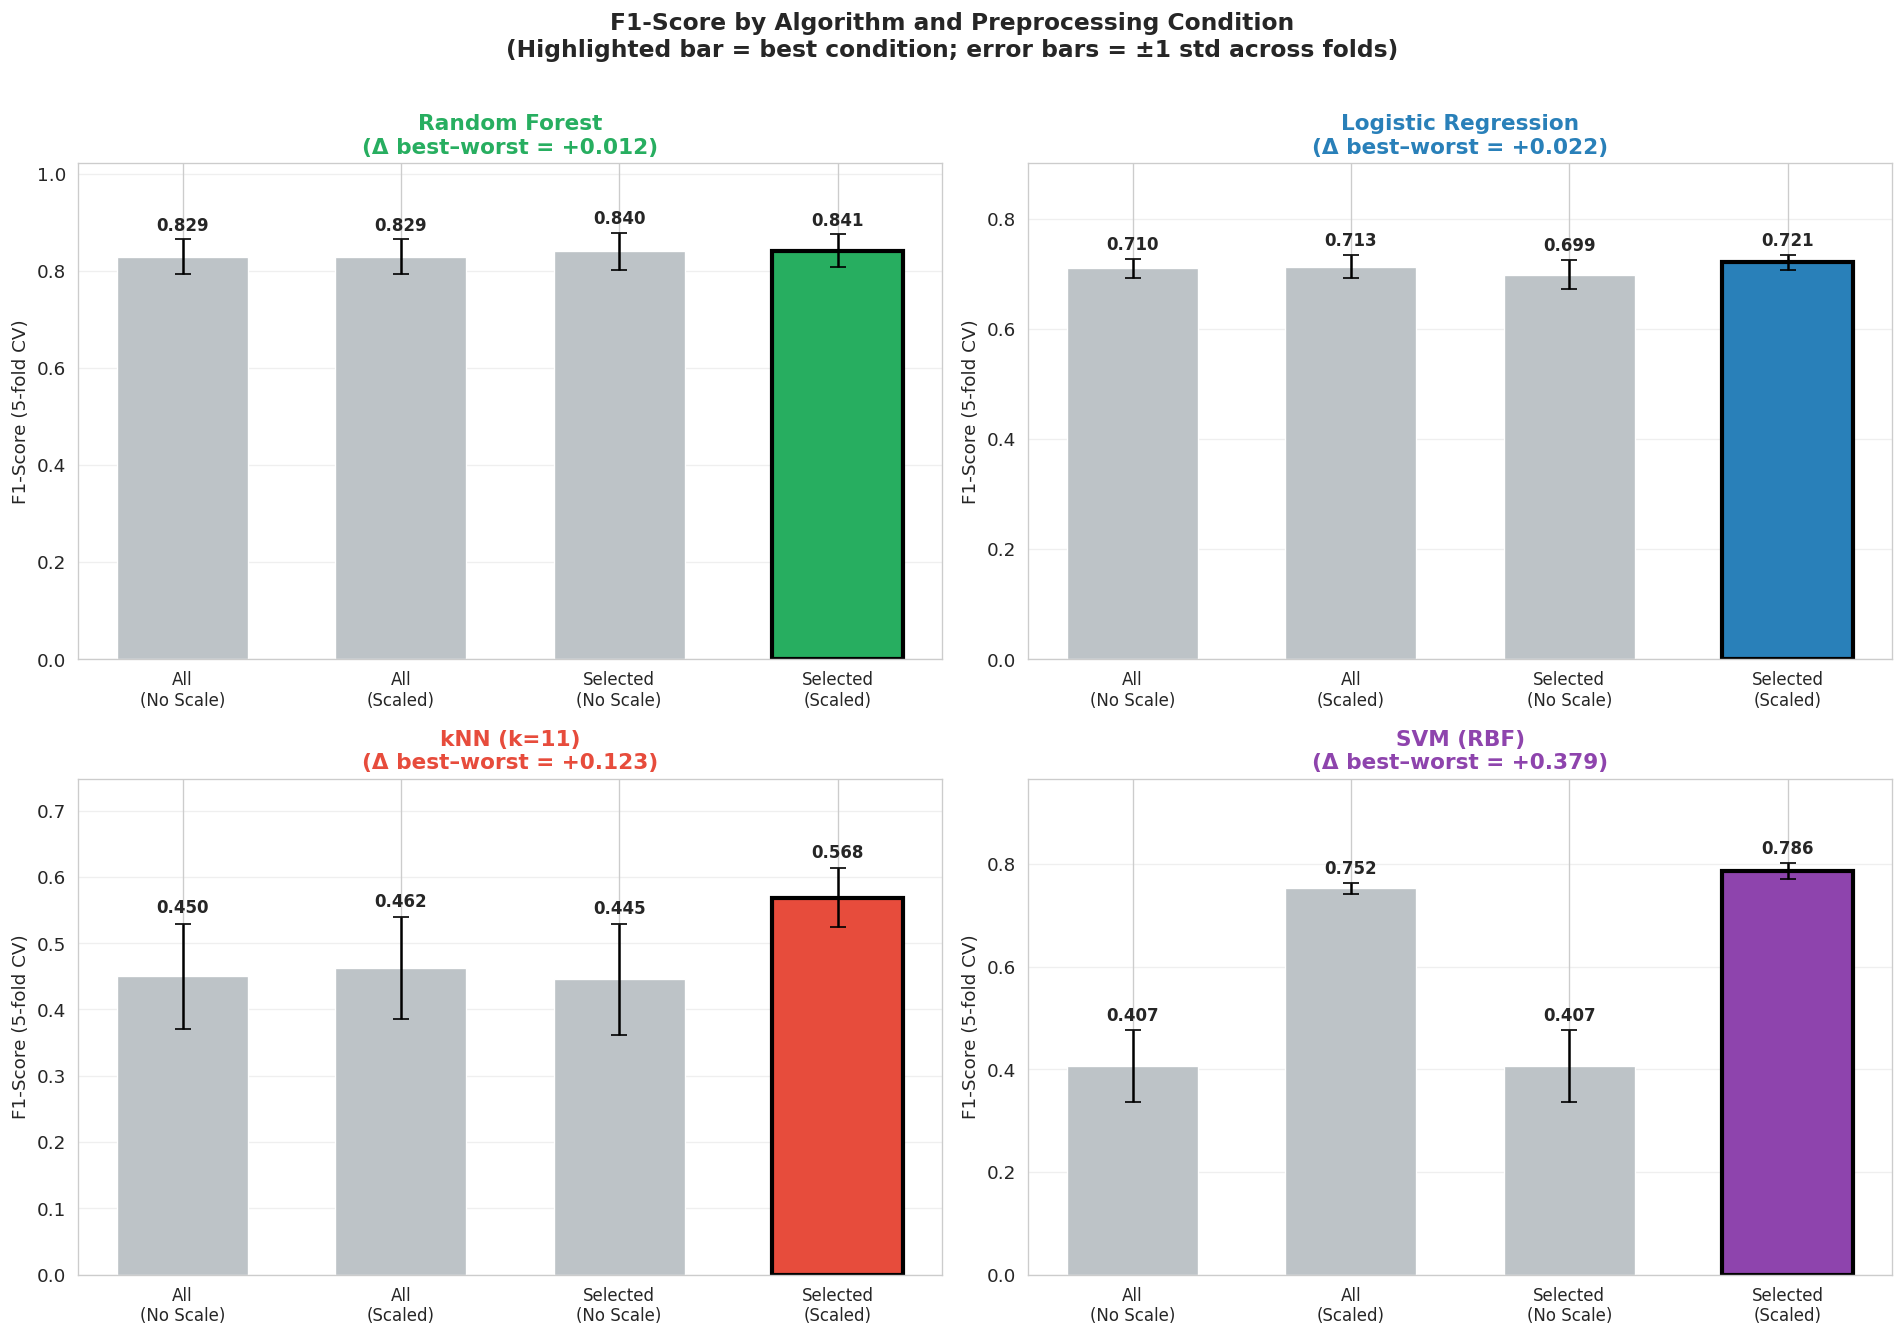

In [7]:
algo_colors = {
    'Random Forest':       '#27ae60',
    'Logistic Regression': '#2980b9',
    'kNN (k=11)':          '#e74c3c',
    'SVM (RBF)':           '#8e44ad',
}

conditions_short = ['All\n(No Scale)', 'All\n(Scaled)', 'Selected\n(No Scale)', 'Selected\n(Scaled)']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for idx, (algo_name, color) in enumerate(algo_colors.items()):
    ax = axes[idx]
    algo_data = results_df[results_df['Algorithm'] == algo_name].copy()
    algo_data = algo_data.set_index('Condition').reindex(condition_order)

    f1_vals    = algo_data['F1'].values
    f1_stds    = algo_data['F1_std'].values
    bar_colors = [color if v == max(f1_vals) else '#bdc3c7' for v in f1_vals]
    bar_colors[np.argmax(f1_vals)] = color

    bars = ax.bar(conditions_short, f1_vals, color=bar_colors,
                  edgecolor='white', linewidth=0.8, width=0.6,
                  yerr=f1_stds, capsize=5, error_kw={'color': '#555', 'linewidth': 1.5})

    # Value labels on bars
    for bar, val, std in zip(bars, f1_vals, f1_stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Delta annotation
    delta = max(f1_vals) - min(f1_vals)
    ax.set_title(f'{algo_name}\n(Δ best–worst = {delta:+.3f})', fontsize=13, fontweight='bold', color=color)
    ax.set_ylabel('F1-Score (5-fold CV)', fontsize=11)
    ax.set_ylim(0, min(1.15, max(f1_vals) + 0.18))
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=10)

    # Shade the best bar lightly
    bars[np.argmax(f1_vals)].set_linewidth(2.5)
    bars[np.argmax(f1_vals)].set_edgecolor('black')

plt.suptitle('F1-Score by Algorithm and Preprocessing Condition\n'
             '(Highlighted bar = best condition; error bars = ±1 std across folds)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/algorithm_comparison.png', bbox_inches='tight')
plt.show()

---
## Part 8: Sensitivity Heatmap

This heatmap summarizes which algorithms benefit most from each preprocessing decision. The values show the F1 gain from applying that preprocessing step.

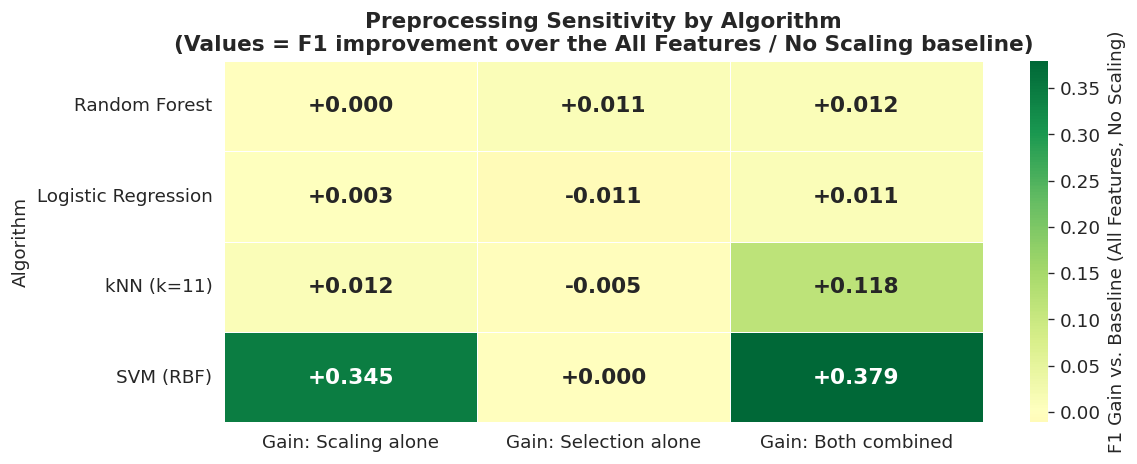

                     Gain: Scaling alone  Gain: Selection alone  Gain: Both combined
Algorithm                                                                           
Random Forest                      0.000                  0.011                0.012
Logistic Regression                0.003                 -0.011                0.011
kNN (k=11)                         0.012                 -0.005                0.118
SVM (RBF)                          0.345                  0.000                0.379


In [8]:
# For each algorithm, compute:
# - Gain from scaling:    (All+Scaled) - (All+NoScale)
# - Gain from selection:  (Selected+NoScale) - (All+NoScale)
# - Combined gain:        (Selected+Scaled)  - (All+NoScale)

cond_map = {
    'All Features\n(No Scaling)':     'all_noscale',
    'All Features\n(Scaled)':         'all_scaled',
    'Selected Features\n(No Scaling)': 'sel_noscale',
    'Selected Features\n(Scaled)':     'sel_scaled',
}

sensitivity = []
for algo_name in algo_colors:
    row = results_df[results_df['Algorithm'] == algo_name].copy()
    row['cond_key'] = row['Condition'].map(cond_map)
    row = row.set_index('cond_key')
    base = row.loc['all_noscale', 'F1']
    sensitivity.append({
        'Algorithm':              algo_name,
        'Gain: Scaling alone':    row.loc['all_scaled',  'F1'] - base,
        'Gain: Selection alone':  row.loc['sel_noscale', 'F1'] - base,
        'Gain: Both combined':    row.loc['sel_scaled',  'F1'] - base,
    })

sens_df = pd.DataFrame(sensitivity).set_index('Algorithm')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(sens_df, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'},
            ax=ax, cbar_kws={'label': 'F1 Gain vs. Baseline (All Features, No Scaling)'})
ax.set_title('Preprocessing Sensitivity by Algorithm\n'
             '(Values = F1 improvement over the All Features / No Scaling baseline)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('/tmp/sensitivity_heatmap.png', bbox_inches='tight')
plt.show()

print(sens_df.round(3).to_string())

---
## Part 9: Understanding WHY — The Mechanics Behind Each Algorithm

Let's go deeper and visualize *why* each algorithm behaves the way it does. We'll examine feature importance (RF), coefficient magnitudes (LR), and distance distortion (kNN/SVM).

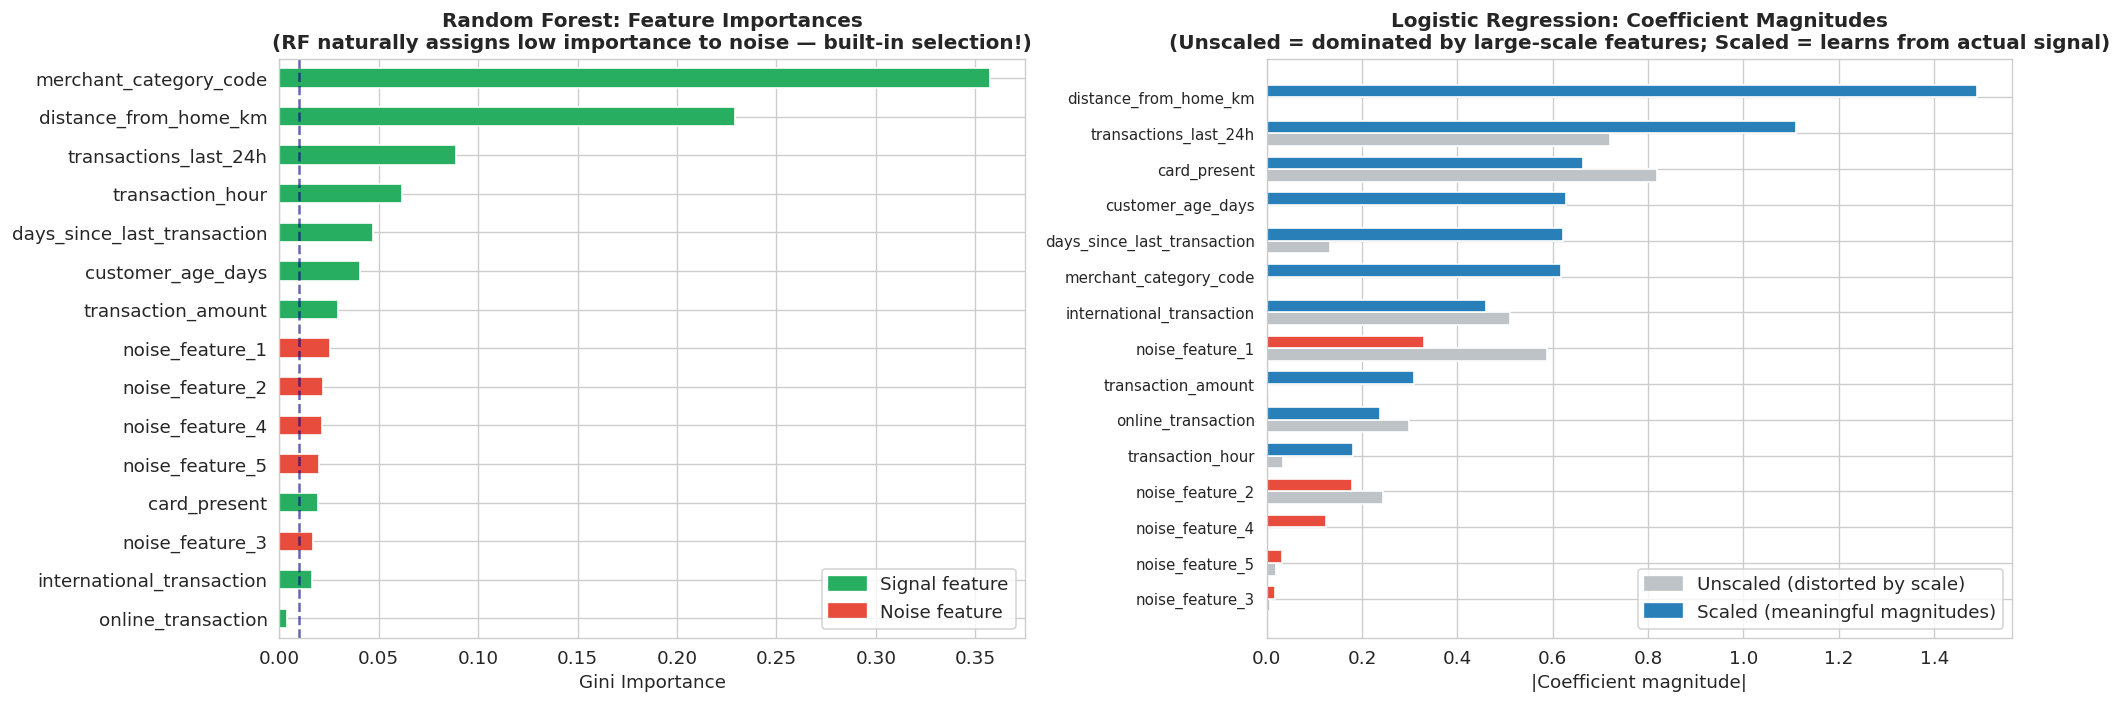

💡 Key observation for Logistic Regression:
   Without scaling, "card_present" dominates with coefficient 0.819169
   This is because that feature has the largest raw values — not because it is the most informative.


In [9]:
# --- Fit final models for inspection ---
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y_full, test_size=0.2, stratify=y_full, random_state=42)

X_train_scaled = StandardScaler().fit_transform(X_train_all)
X_test_scaled  = StandardScaler().fit_transform(X_test_all)  # Note: in production, fit on train only

# Refit scaler properly
sc = StandardScaler().fit(X_train_all)
X_train_scaled = sc.transform(X_train_all)
X_test_scaled  = sc.transform(X_test_all)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ===== LEFT: Random Forest feature importances =====
rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
rf.fit(X_train_all, y_train)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_rf = ['#e74c3c' if 'noise' in f else '#27ae60' for f in rf_imp.index]
rf_imp.plot(kind='barh', ax=axes[0], color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest: Feature Importances\n'
                  '(RF naturally assigns low importance to noise — built-in selection!)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gini Importance', fontsize=11)
signal_patch = mpatches.Patch(color='#27ae60', label='Signal feature')
noise_patch  = mpatches.Patch(color='#e74c3c',  label='Noise feature')
axes[0].legend(handles=[signal_patch, noise_patch])
axes[0].axvline(0.01, color='navy', linestyle='--', alpha=0.6, label='Importance = 0.01')

# ===== RIGHT: Logistic Regression — unscaled vs. scaled coefficients =====
lr_unscaled = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(X_train_all, y_train)
lr_scaled   = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Unscaled': np.abs(lr_unscaled.coef_[0]),
    'Scaled':   np.abs(lr_scaled.coef_[0])
}, index=X.columns).sort_values('Scaled', ascending=True)

x_pos = np.arange(len(coef_df))
w = 0.35
colors_bar = ['#e74c3c' if 'noise' in f else '#2980b9' for f in coef_df.index]

axes[1].barh(x_pos - w/2, coef_df['Unscaled'], height=w, color='#bdc3c7', label='Unscaled coefficients', edgecolor='white')
axes[1].barh(x_pos + w/2, coef_df['Scaled'],   height=w, color=colors_bar, label='Scaled coefficients', edgecolor='white')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(coef_df.index, fontsize=9)
axes[1].set_xlabel('|Coefficient magnitude|', fontsize=11)
axes[1].set_title('Logistic Regression: Coefficient Magnitudes\n'
                  '(Unscaled = dominated by large-scale features; Scaled = learns from actual signal)',
                  fontsize=12, fontweight='bold')

unscaled_patch = mpatches.Patch(color='#bdc3c7', label='Unscaled (distorted by scale)')
scaled_patch   = mpatches.Patch(color='#2980b9', label='Scaled (meaningful magnitudes)')
axes[1].legend(handles=[unscaled_patch, scaled_patch])

plt.tight_layout()
plt.show()

print('💡 Key observation for Logistic Regression:')
biggest_unscaled = coef_df['Unscaled'].idxmax()
print(f'   Without scaling, "{biggest_unscaled}" dominates with coefficient {coef_df.loc[biggest_unscaled,"Unscaled"]:.6f}')
print(f'   This is because that feature has the largest raw values — not because it is the most informative.')

---
## Part 10: The kNN Distance Distortion Problem

kNN is the most visually intuitive algorithm for demonstrating scale sensitivity. Its entire decision logic is: *"find the k nearest neighbors and take a majority vote."* If one feature has values in the hundreds of thousands and another is 0 or 1, the binary feature becomes **mathematically invisible** in the distance calculation.

We can demonstrate this directly by looking at how much each feature *actually contributes* to the average pairwise distance.

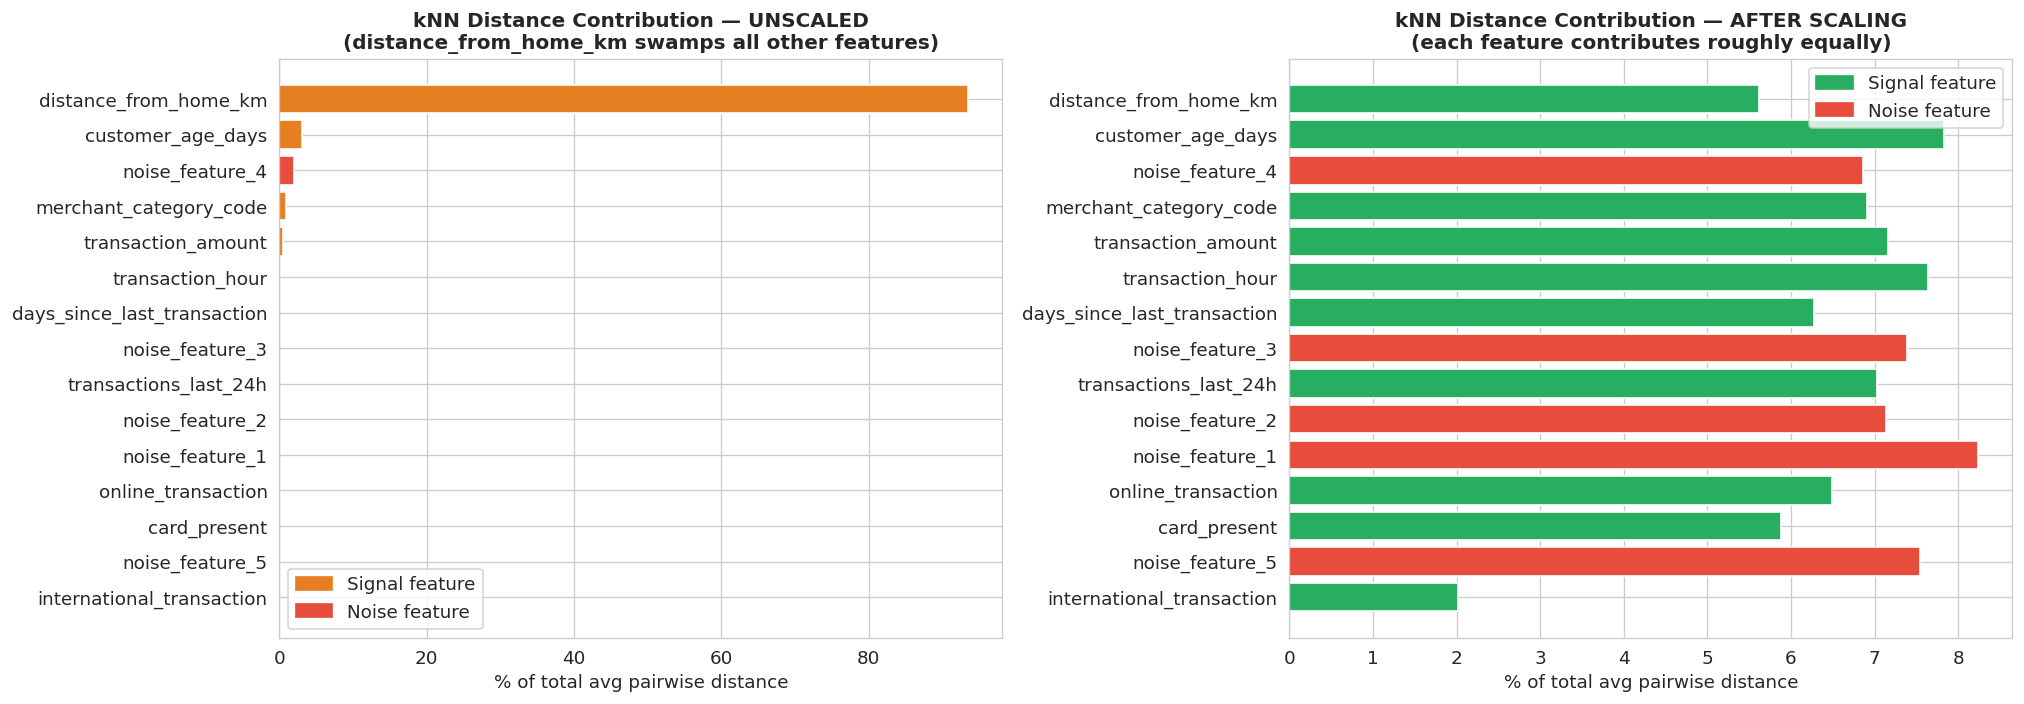

📌 Without scaling: "distance_from_home_km" contributes 93.5% of total distance.
   Features like "online_transaction" (binary 0/1) contribute effectively 0%.
   kNN is essentially making decisions based on one feature only.

   After scaling: each feature contributes roughly 7% — all features get a vote.


In [10]:
from sklearn.metrics import pairwise_distances

# Sample 200 points for computational efficiency
sample_idx = np.random.choice(len(X_all), 200, replace=False)
X_sample        = X_all[sample_idx]
X_sample_scaled = X_train_scaled[:200] if len(X_train_scaled) >= 200 else X_train_scaled
X_sample_scaled = sc.transform(X_all[sample_idx])

# Contribution of each feature to total pairwise distance (unscaled)
feature_dist_contribution_raw    = []
feature_dist_contribution_scaled = []

for i, feat in enumerate(X.columns):
    raw_col    = X_sample[:, i].reshape(-1, 1)
    scaled_col = X_sample_scaled[:, i].reshape(-1, 1)
    feature_dist_contribution_raw.append(pairwise_distances(raw_col).mean())
    feature_dist_contribution_scaled.append(pairwise_distances(scaled_col).mean())

contrib_df = pd.DataFrame({
    'Feature':       list(X.columns),
    'Raw':           feature_dist_contribution_raw,
    'Scaled':        feature_dist_contribution_scaled,
    'Type':          ['Noise' if 'noise' in f else 'Signal' for f in X.columns]
}).sort_values('Raw', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Pct of total distance contributed by each feature
contrib_df['Raw_pct']    = contrib_df['Raw']    / contrib_df['Raw'].sum() * 100
contrib_df['Scaled_pct'] = contrib_df['Scaled'] / contrib_df['Scaled'].sum() * 100

colors_left  = ['#e74c3c' if t == 'Noise' else '#e67e22' for t in contrib_df['Type']]
colors_right = ['#e74c3c' if t == 'Noise' else '#27ae60' for t in contrib_df['Type']]

axes[0].barh(contrib_df['Feature'], contrib_df['Raw_pct'], color=colors_left, edgecolor='white')
axes[0].set_title('kNN Distance Contribution — UNSCALED\n'
                  '(distance_from_home_km swamps all other features)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% of total avg pairwise distance', fontsize=11)
signal_p = mpatches.Patch(color='#e67e22', label='Signal feature')
noise_p  = mpatches.Patch(color='#e74c3c',  label='Noise feature')
axes[0].legend(handles=[signal_p, noise_p])

axes[1].barh(contrib_df['Feature'], contrib_df['Scaled_pct'], color=colors_right, edgecolor='white')
axes[1].set_title('kNN Distance Contribution — AFTER SCALING\n'
                  '(each feature contributes roughly equally)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% of total avg pairwise distance', fontsize=11)
signal_p2 = mpatches.Patch(color='#27ae60', label='Signal feature')
noise_p2  = mpatches.Patch(color='#e74c3c',  label='Noise feature')
axes[1].legend(handles=[signal_p2, noise_p2])

plt.tight_layout()
plt.show()

top_raw = contrib_df.sort_values('Raw_pct', ascending=False).iloc[0]
print(f'📌 Without scaling: "{top_raw["Feature"]}" contributes {top_raw["Raw_pct"]:.1f}% of total distance.')
print(f'   Features like "online_transaction" (binary 0/1) contribute effectively 0%.')
print(f'   kNN is essentially making decisions based on one feature only.')
print(f'\n   After scaling: each feature contributes roughly {100/len(X.columns):.0f}% — all features get a vote.')

---
## Part 11: Final Summary and Key Takeaways

In [11]:
# Final summary table — all metrics for best condition per algorithm
print('\n' + '='*75)
print('📊 SUMMARY: Best Condition per Algorithm (5-fold CV Mean Scores)')
print('='*75)

for algo in algo_colors:
    algo_rows = results_df[results_df['Algorithm'] == algo]
    best_row  = algo_rows.loc[algo_rows['F1'].idxmax()]
    worst_row = algo_rows.loc[algo_rows['F1'].idxmin()]
    cond_clean = best_row['Condition'].replace('\n', ' ')
    print(f'\n  {algo}')
    print(f'    Best condition : {cond_clean}')
    print(f'    F1  (best)     : {best_row["F1"]:.3f}   |   F1 (worst): {worst_row["F1"]:.3f}   |   Δ: {best_row["F1"]-worst_row["F1"]:+.3f}')
    print(f'    Recall (best)  : {best_row["Recall"]:.3f}')
    print(f'    ROC-AUC (best) : {best_row["ROC-AUC"]:.3f}')

print('\n' + '='*75)


📊 SUMMARY: Best Condition per Algorithm (5-fold CV Mean Scores)

  Random Forest
    Best condition : Selected Features (Scaled)
    F1  (best)     : 0.841   |   F1 (worst): 0.829   |   Δ: +0.012
    Recall (best)  : 0.756
    ROC-AUC (best) : 0.980

  Logistic Regression
    Best condition : Selected Features (Scaled)
    F1  (best)     : 0.721   |   F1 (worst): 0.699   |   Δ: +0.022
    Recall (best)  : 0.616
    ROC-AUC (best) : 0.960

  kNN (k=11)
    Best condition : Selected Features (Scaled)
    F1  (best)     : 0.568   |   F1 (worst): 0.445   |   Δ: +0.123
    Recall (best)  : 0.400
    ROC-AUC (best) : 0.902

  SVM (RBF)
    Best condition : Selected Features (Scaled)
    F1  (best)     : 0.786   |   F1 (worst): 0.407   |   Δ: +0.379
    Recall (best)  : 0.684
    ROC-AUC (best) : 0.950



---
## Part 12: Key Takeaways

### 🌲 Random Forest — "The Robust Generalist"
Random Forest shows **minimal sensitivity** to both feature selection and scaling. Why?
- Each tree sees a **random subset of features** at every split, so noise features get bypassed naturally
- Decision trees split on thresholds, which are **scale-invariant** by definition
- The ensemble averages away the variance introduced by occasional bad splits on noise features

**Implication:** RF is forgiving of messy feature sets. You can throw raw, unscaled, noisy features at it and still get strong results. This is why practitioners often use RF as a quick baseline — it just works.

---

### 📈 Logistic Regression — "Scale First, Always"
LR is a **linear model** — it assigns a coefficient to each feature. Without scaling:
- Coefficients are distorted by raw magnitude, not informational value
- A feature stored in meters gets a coefficient ~1000x larger than the same feature stored in km — even though they encode identical information
- Regularization (L2 penalty) penalizes large coefficients, so unscaled high-magnitude features get *over-penalized*

**Implication:** Always scale before Logistic Regression. Feature selection also helps — irrelevant features add noise to the coefficient optimization landscape.

---

### 📍 kNN — "Scale or Don't Bother"
kNN makes decisions purely on **Euclidean distance**. Without scaling:
- One high-magnitude feature can account for >90% of the total distance
- All other features — including informative ones — become mathematically invisible
- The model is effectively a 1-feature model disguised as a 15-feature model

Feature selection also matters because irrelevant features add noise dimensions that dilute true distances. The combination of scaling + selection produces the largest absolute gain for kNN.

**Implication:** kNN without scaling is not a model — it's a mistake. Always scale.

---

### ⚙️ SVM (RBF) — "Needs Scale, Benefits from Selection"
SVM with an RBF kernel uses **kernel distances** to map data to a higher-dimensional space. The RBF kernel is `exp(-γ||x - x'||²)` — if distances are dominated by one unscaled feature, the kernel becomes uninformative (all points look equally far away or equally close).

Feature selection helps by reducing the dimensionality of the kernel computation and removing noise that disrupts the margin calculation.

**Implication:** SVM requires scaling. Feature selection provides additional but less dramatic gains.

---

### 🎓 The Universal Decision Framework

When you're choosing preprocessing steps, ask:

```
Does my algorithm use distance or gradient magnitude?  →  YES: scale first, always
   (kNN, SVM, Logistic Regression, Neural Networks, PCA)

Does my algorithm split on feature thresholds?         →  Scaling won't help
   (Decision Trees, Random Forest, Gradient Boosting)

Do I have many potentially irrelevant features?        →  Feature selection helps
   (especially for kNN and linear models)
   
Is my primary algorithm tree-based?                    →  RF handles noise naturally;
   focus your effort on hyperparameter tuning instead.
```

> **The most important lesson:** Feature selection and scaling are not universally beneficial — they are tools that match specific algorithm mechanics. Understanding *why* an algorithm is or isn't sensitive to preprocessing is more valuable than memorizing that preprocessing is always good.